In [9]:
# Labial 

import sys
sys.path.append('/volume_4/research/seongbong/flywire/geosmin_project_version_update/code')
from analysis_of_simulation_result import * 

import numpy as np 
import pandas as pd 
import os 
import pickle
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from cell_groups import *

# import matplotlib
# import matplotlib.pyplot as plt
# matplotlib.rcParams['svg.fonttype'] = 'none'
# matplotlib.rcParams['font.family'] = 'Arial'
# matplotlib.rcParams['font.size'] = 7

In [10]:
from scipy.stats import hmean

DATA_DIR = Path.cwd().resolve().parents[0]/'data'

def load_screening_result(filename, sheet_name):
    df = pd.read_excel(
        DATA_DIR / filename,
        sheet_name=sheet_name,
        header=1,
        index_col=0,
    )

    if "type" in df.index:
        df = df.drop(index="type")

    df.index.name = "type"
    return df

def calculate_network_characteristics(activation,silence,mode='sweet'):
    
    df_per_concent = {}
    for concent in silence.columns:
        if mode == 'sweet':
            slnc = silence[concent]
            act = activation[0]
            N = (slnc.loc['control'] - slnc)/slnc.loc['control']
            S = act - act.loc['control']
        else:
            slnc = silence[concent]
            act = activation[concent]
            N = (slnc - slnc.loc['control'])/slnc.loc['control']
            S = (act.loc['control'] - act)/act.loc['control']
        N = N.clip(lower=0)
        S = S.clip(lower=0)
        N, S = N.align(S)
        HM = hmean(np.vstack([N,S]))
        df = pd.DataFrame({
            'Necessity': N,
            'Sufficiency': S,
            'HM': HM
        }, index=N.index)    
        df[f'rank_v{concent}'] = df['HM'].rank(ascending=False, method='min').astype(int)
        df_per_concent[concent] = df 
    
    return df_per_concent 



### Sweet ###
# Tarsal
tarsal_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "tarsal",
)
tarsal_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "tarsal",
)


# Labellar
labial_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "labellar",
)
labial_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "labellar",
)
labial_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "labellar",
)



### Sweet ###
# Tarsal
tarsal_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "labellar",
)
labial_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "labellar",
)
labial_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "labellar",
)




tarsal_sweet_df = calculate_network_characteristics(tarsal_activation_per,tarsal_screening_per,mode='sweet')
labial_sweet_df = calculate_network_characteristics(labial_activation_per,labial_screening_per,mode='sweet')
tarsal_geosmin_df = calculate_network_characteristics(tarsal_geosmin_activation_per,tarsal_geosmin_screening_per,mode='geosmin')
labial_geosmin_df = calculate_network_characteristics(labial_geosmin_activation_per,labial_geosmin_screening_per,mode='geosmin')


In [17]:
sez_ids = np.concatenate(list(sez.values()))
fid2sez_g = {c:t for t,cids in sez.items() for c in cids}

gids = np.unique(np.concatenate([tarsal_activation_per.index[1:],labial_activation_per.index[1:],tarsal_geosmin_activation_per.index[1:],labial_geosmin_activation_per.index[1:]]))

canonical_name = []
for g in gids:
    g = int(g)
    fids = target_ids_valid_all[g_info_all==g]
    if np.any(np.isin(fids,sez_ids)):
        canonical_name.append(fid2sez_g[fids[np.isin(fids,sez_ids)][0]])
    else:
        canonical_name.append(str(g))
gid2canonical_name = dict(zip(gids,canonical_name))
gid2canonical_name['control'] = 'control'

In [18]:
from functools import reduce

import matplotlib.pyplot as plt
import pandas as pd


def merge_rank_tables(df_dict, rank_col='rank'):
    """
    농도별 DataFrame dictionary에서 rank column만 추출하여 병합합니다.

    Parameters
    ----------
    df_dict : dict
        {concentration: DataFrame} 형태
    rank_col : str
        각 DataFrame에서 사용할 rank column 이름

    Returns
    -------
    pd.DataFrame
        index: neuron type
        columns: rank_10, rank_50, rank_100, ...
    """
    dfs = []

    for concentration, df in df_dict.items():
        df = df.drop('control')
        df_ = df.loc[~df.index.duplicated(keep='first')].copy()

        # 정확한 rank column이 없으면 rank_로 시작하는 column 탐색
        if rank_col in df_.columns:
            current_rank_col = rank_col
        else:
            rank_candidates = [
                col for col in df_.columns
                if col.startswith('rank_')
            ]

            if len(rank_candidates) == 0:
                raise KeyError(
                    f'{concentration} 데이터에서 rank column을 찾을 수 없습니다.'
                )

            current_rank_col = rank_candidates[0]

        rank_df = df_[[current_rank_col]].rename(
            columns={current_rank_col: f'rank_{concentration}'}
        )

        dfs.append(rank_df)

    return reduce(
        lambda left, right: left.join(right, how='outer'),
        dfs
    )


def get_canonical_name(group_id, gid2canonical_name):
    """group ID에 대응하는 canonical name을 반환합니다."""
    return gid2canonical_name.get(group_id, str(group_id))


def plot_rank_transition(
    ax,
    df,
    concentration_from,
    concentration_to,
    gid2canonical_name,
    top_n=20,
    x_positions=(1, 1.5),
):
    """
    두 농도 사이의 top-N rank 변화를 표시합니다.
    """
    col_from = f'rank_{concentration_from}'
    col_to = f'rank_{concentration_to}'

    required_columns = [col_from, col_to]
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise KeyError(f'필요한 column이 없습니다: {missing_columns}')

    # 시작 농도에서 top N인 neuron 선택
    top_df = (
        df.loc[df[col_from] <= top_n, [col_from, col_to]]
        .dropna()
        .sort_values(col_from)
    )

    x1, x2 = x_positions

    # 각 neuron의 rank transition
    for _, row in top_df.iterrows():
        ax.plot(
            [x1, x2],
            [row[col_from], row[col_to]],
            marker='o'
        )

    ax.set_xticks(
        [x1, x2],
        [f'{concentration_from} mM', f'{concentration_to} mM']
    )

    ax.set_yticks(
        top_df[col_from],
        [
            get_canonical_name(group_id, gid2canonical_name)
            for group_id in top_df.index
        ]
    )

    ax.invert_yaxis()

    # 오른쪽 축에 도착 rank 표시
    secax = ax.secondary_yaxis('right')
    secax.set_yticks(
        top_df[col_to],
        top_df[col_to].astype(int)
    )

    ax.set_xlim(x1 - 0.1, x2 + 0.1)

    return top_df

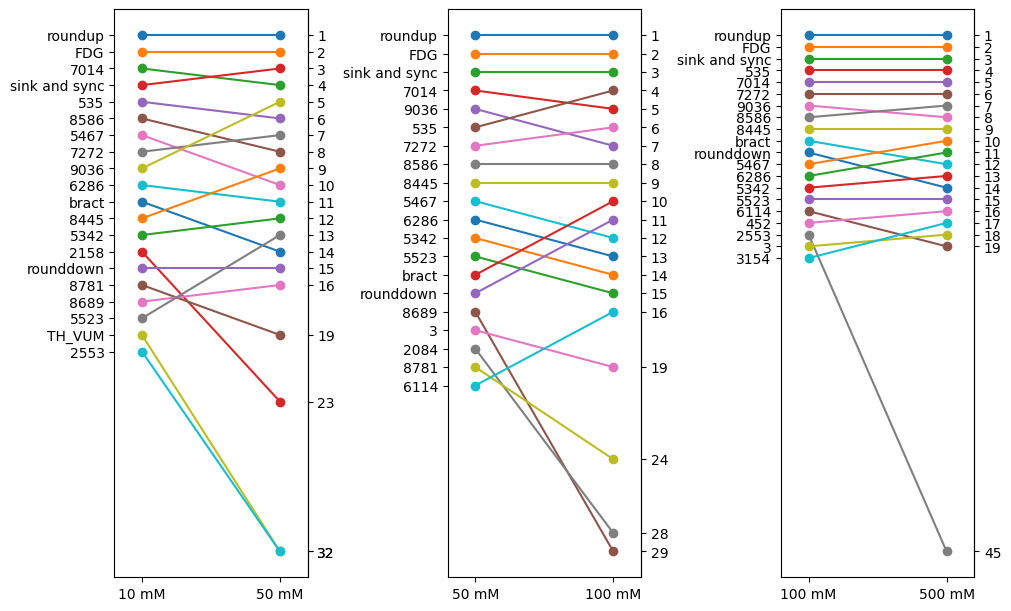

In [7]:
df_merged = merge_rank_tables(
    tarsal_sweet_df,
    rank_col='rank'
)

concentration_pairs = [
    (10, 50),
    (50, 100),
    (100, 500),
]

fig, axes = plt.subplots(
    1,
    len(concentration_pairs),
    figsize=(10, 6),
    constrained_layout=True
)

top_dfs = {}

for ax, (concentration_from, concentration_to) in zip(
    axes,
    concentration_pairs
):
    top_dfs[(concentration_from, concentration_to)] = (
        plot_rank_transition(
            ax=ax,
            df=df_merged,
            concentration_from=concentration_from,
            concentration_to=concentration_to,
            gid2canonical_name=gid2canonical_name,
            top_n=20
        )
    )

plt.show()

df_merged.to_parquet('data/tarsal_sweet_rank.parquet')

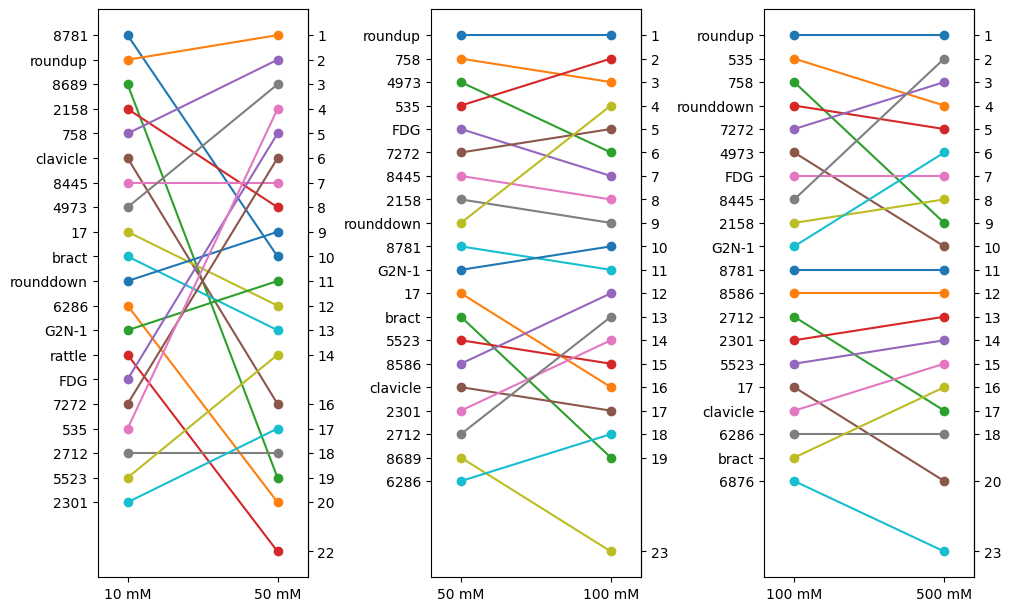

In [8]:
df_merged = merge_rank_tables(
    labial_sweet_df,
    rank_col='rank'
)

concentration_pairs = [
    (10, 50),
    (50, 100),
    (100, 500),
]

fig, axes = plt.subplots(
    1,
    len(concentration_pairs),
    figsize=(10, 6),
    constrained_layout=True
)

top_dfs = {}

for ax, (concentration_from, concentration_to) in zip(
    axes,
    concentration_pairs
):
    top_dfs[(concentration_from, concentration_to)] = (
        plot_rank_transition(
            ax=ax,
            df=df_merged,
            concentration_from=concentration_from,
            concentration_to=concentration_to,
            gid2canonical_name=gid2canonical_name,
            top_n=20
        )
    )

plt.show()

df_merged.to_parquet('data/labial_sweet_rank.parquet')

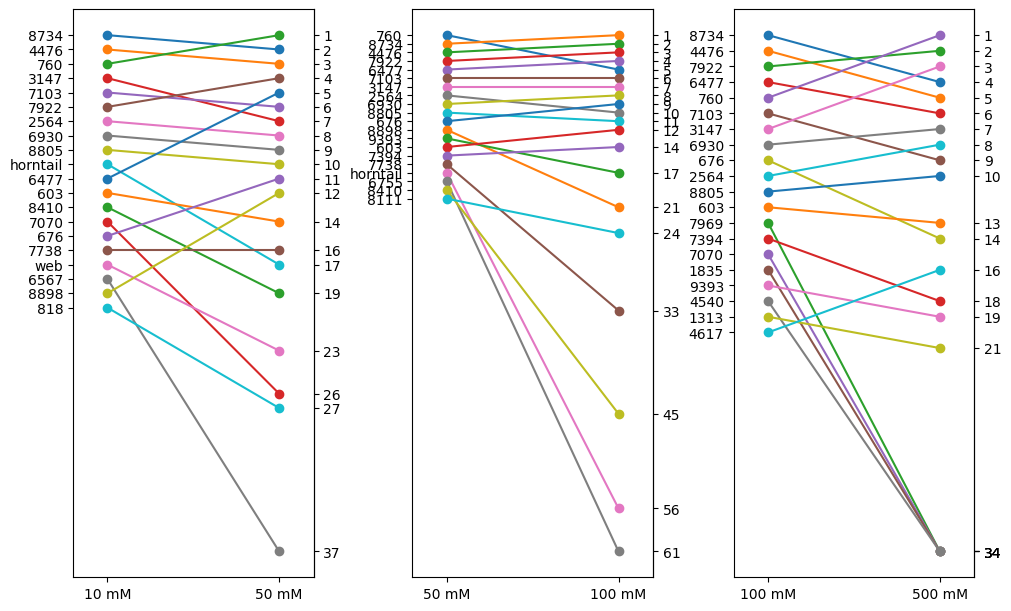

In [9]:
df_merged = merge_rank_tables(
    tarsal_geosmin_df,
    rank_col='rank'
)

concentration_pairs = [
    (10, 50),
    (50, 100),
    (100, 500),
]

fig, axes = plt.subplots(
    1,
    len(concentration_pairs),
    figsize=(10, 6),
    constrained_layout=True
)

top_dfs = {}

for ax, (concentration_from, concentration_to) in zip(
    axes,
    concentration_pairs
):
    top_dfs[(concentration_from, concentration_to)] = (
        plot_rank_transition(
            ax=ax,
            df=df_merged,
            concentration_from=concentration_from,
            concentration_to=concentration_to,
            gid2canonical_name=gid2canonical_name,
            top_n=20
        )
    )

plt.show()

df_merged.to_parquet('data/tarsal_geosmin_rank.parquet')

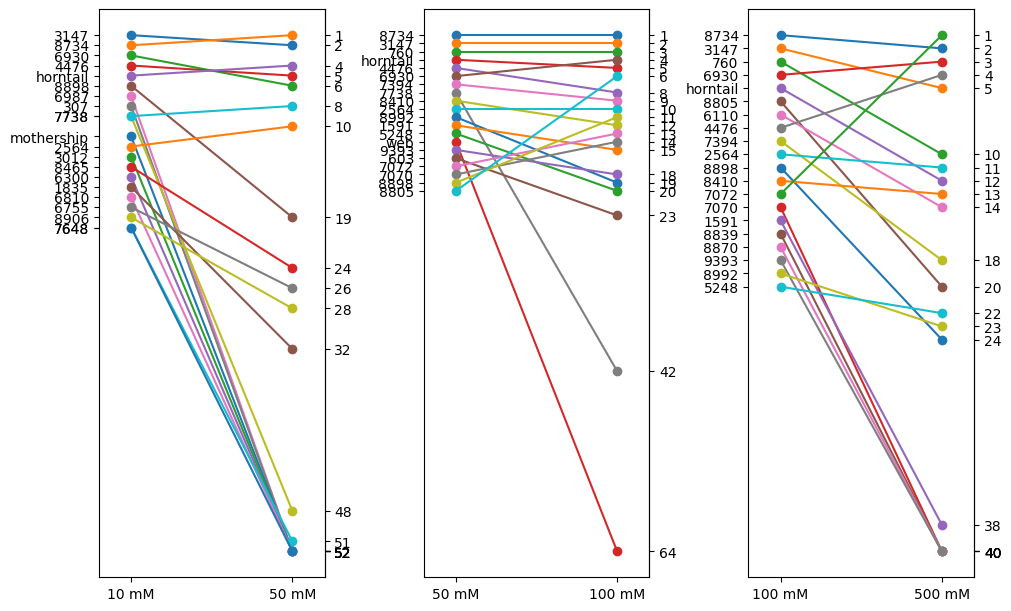

In [10]:
df_merged = merge_rank_tables(
    labial_geosmin_df,
    rank_col='rank'
)

concentration_pairs = [
    (10, 50),
    (50, 100),
    (100, 500),
]

fig, axes = plt.subplots(
    1,
    len(concentration_pairs),
    figsize=(10, 6),
    constrained_layout=True
)

top_dfs = {}

for ax, (concentration_from, concentration_to) in zip(
    axes,
    concentration_pairs
):
    top_dfs[(concentration_from, concentration_to)] = (
        plot_rank_transition(
            ax=ax,
            df=df_merged,
            concentration_from=concentration_from,
            concentration_to=concentration_to,
            gid2canonical_name=gid2canonical_name,
            top_n=20
        )
    )

plt.show()

df_merged.to_parquet('data/labial_geosmin_rank.parquet')

In [11]:
df_merged.loc['control']

KeyError: 'control'